# GRADE --- the whole study, end to end

Run top to bottom. Everything is here: corpus, splits, audits, controls,
training, results, figures and the LaTeX for the paper.

**Two questions**

- **RQ1.** Does a detector trained on a set of assignments work on an
  assignment it has never seen?
- **RQ2.** When it is wrong about authentic student work, which students
  absorb the error?

**Cost.** Sections 1--3 take minutes. Section 4 is the GPU sweep, about 8
hours; it appends each finished fold to disk and skips it on restart, so it can
be interrupted freely. Sections 5--8 take seconds.

## 0. Environment

In [1]:
import os, sys, gc, re, json, time, random, hashlib, warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('TRANSFORMERS_VERBOSITY', 'error')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

REPO     = os.path.abspath('..')
DATASETS = os.path.join(REPO, 'datasets')
DATA     = os.path.join(REPO, 'data')
LOTO     = os.path.join(DATA, 'loto')
RESULTS  = os.path.join(REPO, 'results')
PREDS    = os.path.join(RESULTS, 'loto_predictions')
CKPT     = os.path.join(REPO, 'models', 'loto')
FIGS     = os.path.join(RESULTS, 'figures')
for d in (LOTO, RESULTS, PREDS, CKPT, FIGS):
    os.makedirs(d, exist_ok=True)

MERGED   = os.path.join(DATASETS, 'merged', 'essays_merged.csv')
PERSUADE = os.path.join(DATASETS, 'Persuade 2.0',
                        'persuade_2.0_human_scores_demo_id_github.csv')
ABSTRACTS = os.path.join(DATA, 'eval_abstract.csv')
RUNS     = os.path.join(RESULTS, 'loto_runs.csv')
ABS_RUNS = os.path.join(RESULTS, 'loto_abstract_probe.csv')
BASE     = os.path.join(RESULTS, 'loto_baselines.csv')

SEED = 42
def h(s):
    return hashlib.md5(str(s).strip().lower().encode('utf8','ignore')).hexdigest()

import torch
print('torch          ', torch.__version__)
print('cuda available ', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device         ', torch.cuda.get_device_name(0))
    print('vram           ', '%.1f GB' %
          (torch.cuda.get_device_properties(0).total_memory / 1e9))
else:
    print('\n*** NO GPU - section 4 will be impractically slow. ***')
import transformers
print('transformers   ', transformers.__version__)
try:
    import lime; print('lime            OK')
except ImportError:
    print('lime            MISSING -> section 7b will skip. pip install lime')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

torch           2.5.1+cu118
cuda available  True
device          NVIDIA GeForce RTX 3060 Ti
vram            8.6 GB
transformers    4.57.6
lime            OK


## 1. Build the corpus

Two collections of the same student writing. Roughly two thirds of the first is
already inside the second, so they are merged on normalised text rather than
stacked: stacking would put the same essay in the corpus twice and let a later
split place one copy in training and the other in test.

The assignment label comes from the second collection, which records it. The
first records none. Recovering it from vocabulary, assuming the two assignments
named in the competition's own prompt file, gives labels that are only 24%
correct --- the file actually spans 15 assignments.

In [2]:
def slug(name):
    s = re.sub(r'[^a-z0-9]+', '_', str(name).lower()).strip('_')
    return s[:40]

if os.path.exists(MERGED):
    merged = pd.read_csv(MERGED)
    print('loaded existing merge: %d essays' % len(merged))
else:
    dg = pd.read_csv(os.path.join(DATASETS, 'DAIGT V2', 'train_v2_drcat_02.csv'))
    dg = dg.rename(columns={'prompt_name':'topic', 'source':'generator'})
    dg['origin'] = 'daigt'
    dg = dg[['text','label','topic','generator','origin']]

    ld = pd.read_csv(os.path.join(DATASETS, 'llm_detect', 'Training_Essay_Data.csv'))
    ld = ld.rename(columns={'generated':'label'})
    ld['topic'] = pd.NA; ld['generator'] = pd.NA; ld['origin'] = 'llm_detect'
    ld = ld[['text','label','topic','generator','origin']]
    print('DAIGT %d + LLM-Detect %d' % (len(dg), len(ld)))

    both = pd.concat([dg, ld], ignore_index=True)
    both['text'] = both['text'].astype(str)
    both = both[both['text'].str.len() >= 100]
    both['H'] = both['text'].map(h)
    both['label'] = pd.to_numeric(both['label'], errors='coerce').astype('Int64')
    both = both.dropna(subset=['label'])

    conf = both.groupby('H')['label'].nunique()
    bad = set(conf[conf > 1].index)
    if bad:
        print('dropped %d texts with conflicting labels' % len(bad))
        both = both[~both['H'].isin(bad)]

    both['pref'] = (both['origin'] != 'daigt').astype(int)
    both = both.sort_values(['H','pref'])
    shared = both.groupby('H')['origin'].nunique()
    in_both = set(shared[shared > 1].index)

    merged = both.drop_duplicates('H', keep='first').copy()
    merged['origin'] = merged['H'].map(
        lambda k: 'both' if k in in_both else None).fillna(merged['origin'])
    merged['generator'] = merged['generator'].fillna('unknown')
    merged.loc[merged['label'] == 0, 'generator'] = 'student'

    counts = merged['topic'].value_counts()
    ids = {t: i for i, t in enumerate(counts.index)}
    merged['topic_id'] = merged['topic'].map(ids).astype('Int64')
    merged['topic_slug'] = merged['topic'].map(
        lambda t: slug(t) if pd.notna(t) else pd.NA)
    merged['uid'] = merged['H']
    merged = merged[['uid','text','label','topic','topic_id','topic_slug',
                     'generator','origin']]
    merged = merged.sample(frac=1, random_state=SEED).reset_index(drop=True)
    os.makedirs(os.path.dirname(MERGED), exist_ok=True)
    merged.to_csv(MERGED, index=False)
    print('merged -> %d unique essays' % len(merged))

labelled = merged[merged['topic'].notna()].copy()
print()
print('unique essays      : %6d' % len(merged))
print('  assignment known : %6d   <- used' % len(labelled))
print('  unknown          : %6d   <- excluded (could be the held-out one)'
      % (len(merged) - len(labelled)))
print('student / generated: %d / %d'
      % ((labelled.label==0).sum(), (labelled.label==1).sum()))
print('assignments        : %d' % labelled['topic'].nunique())
print('named generators   : %d' % labelled[labelled.label==1]['generator'].nunique())

loaded existing merge: 54342 essays

unique essays      :  54342
  assignment known :  44861   <- used
  unknown          :   9481   <- excluded (could be the held-out one)
student / generated: 27367 / 17494
assignments        : 15
named generators   : 16


In [3]:
c = labelled.assign(chars=labelled['text'].str.len())
ms, ma = c[c.label==0].chars.median(), c[c.label==1].chars.median()
print('median chars  student %d  generated %d   ratio %.2f:1' % (ms, ma, ms/ma))
print('(lengths are close, so a length-only control has little to exploit)')
print()
ct = pd.crosstab(labelled['topic'], labelled['label'])
ct.columns = ['student','generated']; ct['total'] = ct.sum(1)
ct['smaller_class'] = ct[['student','generated']].min(1)
ct.sort_values('total', ascending=False)

median chars  student 2131  generated 1974   ratio 1.08:1
(lengths are close, so a length-only control has little to exploit)



,student,generated,total,smaller_class
topic,,,,
Distance learning,2157,3396,5553,2157
Seeking multiple opinions,1552,3624,5176,1552
Car-free cities,2665,2051,4716,2051
Does the electoral college work?,2712,1720,4432,1720
Facial action coding system,2167,917,3084,917
Mandatory extracurricular activities,1670,1406,3076,1406
Summer projects,1750,951,2701,951
Driverless cars,1886,364,2250,364
Exploring Venus,1862,314,2176,314


## 2. Leave-one-assignment-out splits

One assignment held out at a time: train on the other 14, mark only on the one
withheld. Every test decision therefore concerns an assignment absent from
training.

Three properties are **enforced**, not assumed. The cell raises rather than
warns, so a bad split cannot reach training.

In [4]:
from sklearn.model_selection import train_test_split
VAL_FRAC, MIN_TEST_PER_CLASS = 0.15, 150

def balance(df, rng):
    n = df['label'].value_counts().min()
    return pd.concat([df[df.label==0].sample(n, random_state=rng),
                      df[df.label==1].sample(n, random_state=rng)]
                    ).sample(frac=1, random_state=rng).reset_index(drop=True)

if os.path.exists(os.path.join(LOTO, 'folds.csv')):
    folds = pd.read_csv(os.path.join(LOTO, 'folds.csv'))
    print('loaded existing folds: %d' % len(folds))
else:
    m = labelled.copy(); m['H'] = m['text'].map(h)
    sizes = (m.groupby('topic')['label'].apply(lambda s: s.value_counts().min())
             .sort_values(ascending=False))
    usable = sizes[sizes >= MIN_TEST_PER_CLASS]
    print('topics with >=%d per class: %d of %d'
          % (MIN_TEST_PER_CLASS, len(usable), len(sizes)))

    rows = []
    for fid, topic in enumerate(usable.index):
        rng = SEED + fid
        test = balance(m[m['topic']==topic], rng)
        rest_b = balance(m[m['topic']!=topic], rng)
        tr_i, va_i = train_test_split(np.arange(len(rest_b)), test_size=VAL_FRAC,
                                      random_state=rng, stratify=rest_b['label'])
        train, val = balance(rest_b.iloc[tr_i], rng), balance(rest_b.iloc[va_i], rng)

        for a, b, nm in [(train,val,'train/val'), (train,test,'train/test'),
                         (val,test,'val/test')]:
            assert not (set(a['H']) & set(b['H'])), 'LEAK fold %d %s' % (fid, nm)
        for part, nm in [(train,'train'), (val,'val')]:
            assert (part['topic']==topic).sum()==0, 'TOPIC LEAK fold %d %s'%(fid,nm)
        for part, nm in [(train,'train'), (val,'val'), (test,'test')]:
            vc = part['label'].value_counts()
            assert vc.iloc[0]==vc.iloc[-1], 'UNBALANCED fold %d %s' % (fid, nm)

        cols = ['uid','text','label','topic','generator']
        for part, nm in [(train,'train'), (val,'val'), (test,'test')]:
            part[cols].to_csv(os.path.join(LOTO,'fold_%02d_%s.csv'%(fid,nm)),
                              index=False)
        rows.append({'fold':fid, 'held_out_topic':topic, 'n_train':len(train),
                     'n_val':len(val), 'n_test':len(test),
                     'test_per_class':len(test)//2})
        print('fold %02d  %-38s train=%5d val=%4d test=%5d'
              % (fid, str(topic)[:38], len(train), len(val), len(test)))
    folds = pd.DataFrame(rows)
    folds.to_csv(os.path.join(LOTO,'folds.csv'), index=False)
    print('\nall %d folds pass topic isolation, disjointness and balance' % len(folds))
folds

loaded existing folds: 15


,fold,held_out_topic,n_train,n_val,n_test,test_per_class
0,0,Distance learning,23966,4230,4314,2157
1,1,Car-free cities,26252,4632,4102,2051
2,2,Does the electoral college work?,26814,4732,3440,1720
3,3,Seeking multiple opinions,23578,4160,3104,1552
4,4,Mandatory extracurricular activities,27348,4826,2812,1406
5,5,Summer projects,28122,4962,1902,951
6,6,Facial action coding system,28180,4974,1834,917
7,7,Community service,28804,5084,1100,550
8,8,"""A Cowboy Who Rode the Waves""",28850,5092,1046,523
9,9,Grades for extracurricular activities,28906,5102,980,490


In [5]:
# independent re-audit of whatever is on disk
bad = 0
for r in folds.itertuples():
    parts = {n: pd.read_csv(os.path.join(LOTO,'fold_%02d_%s.csv'%(r.fold,n)))
             for n in ('train','val','test')}
    H = {n: set(d['text'].map(h)) for n, d in parts.items()}
    for a, b in (('train','val'),('train','test'),('val','test')):
        if H[a] & H[b]: print('LEAK fold %02d %s/%s'%(r.fold,a,b)); bad += 1
    for n in ('train','val'):
        if (parts[n]['topic']==r.held_out_topic).any():
            print('TOPIC LEAK fold %02d %s'%(r.fold,n)); bad += 1
    for n, d in parts.items():
        vc = d['label'].value_counts()
        if vc.iloc[0]!=vc.iloc[-1]: print('UNBALANCED fold %02d %s'%(r.fold,n)); bad+=1
assert bad == 0, 'splits are not clean'
print('re-audit clean: %d folds' % len(folds))

re-audit clean: 15 folds


## 3. Control comparisons

Two deliberately unintelligent methods, fitted separately on **each** fold's
held-out set. One sees only how long the essay is. The other sees only which
words appear, with no sense of order or meaning. Neither can recognise
authorship; they establish the score a detector must beat before its
performance can be credited to anything about writing.

CPU only, cached. About 15 minutes the first time.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, recall_score, roc_auc_score,
                             precision_score, f1_score, confusion_matrix)

def controls_for(df):
    X = df['text'].astype(str).tolist(); y = df['label'].astype(int).tolist()
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25,
                                          random_state=SEED, stratify=y)
    out = {}
    Ltr = np.array([[len(t)] for t in Xtr]); Lte = np.array([[len(t)] for t in Xte])
    mm = LogisticRegression(max_iter=2000).fit(Ltr, ytr)
    out['length_only'] = (accuracy_score(yte, mm.predict(Lte)),
                          recall_score(yte, mm.predict(Lte)),
                          roc_auc_score(yte, mm.predict_proba(Lte)[:,1]))
    v = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=200000)
    mm = LogisticRegression(max_iter=2000).fit(v.fit_transform(Xtr), ytr)
    Z = v.transform(Xte)
    out['tfidf'] = (accuracy_score(yte, mm.predict(Z)),
                    recall_score(yte, mm.predict(Z)),
                    roc_auc_score(yte, mm.predict_proba(Z)[:,1]))
    return out

if os.path.exists(BASE):
    base = pd.read_csv(BASE); print('loaded cached controls')
else:
    rows = []
    for r in folds.itertuples():
        te = pd.read_csv(os.path.join(LOTO,'fold_%02d_test.csv'%r.fold))
        for nm,(a,rc,au) in controls_for(te).items():
            rows.append({'fold':r.fold,'held_out_topic':r.held_out_topic,
                         'baseline':nm,'accuracy':a,'recall':rc,'roc_auc':au,
                         'n_test':len(te)})
        print('  fold %02d done' % r.fold, flush=True)
    base = pd.DataFrame(rows); base.to_csv(BASE, index=False)

base.pivot_table(index='held_out_topic', columns='baseline',
                 values='accuracy').mul(100).round(2)

loaded cached controls


baseline,length_only,tfidf
held_out_topic,,
"""A Cowboy Who Rode the Waves""",62.60,99.62
Car-free cities,54.97,99.32
Cell phones at school,62.07,99.57
Community service,64.73,98.55
Distance learning,76.37,99.44
Does the electoral college work?,55.00,98.95
Driverless cars,50.00,98.90
Exploring Venus,52.87,98.73
Facial action coding system,55.77,98.47


## 4. Train

**Stage 1** trains all 15 folds at seed 42, about 8 hours. **Stage 2** repeats
only the best and worst folds at two further seeds, about 2 hours, which is what
separates a real difference between assignments from run-to-run variation.

Resumable: each finished run appends to `results/loto_runs.csv` and is skipped
on restart. Safe to interrupt.

Each fold also scores the 304-abstract corpus while the model is in memory ---
a side probe, governed by the pre-registered rule in `results/DECISIONS.md`.

In [7]:
STAGE  = 1                    # set to 2 after stage 1 finishes
MODEL  = 'deberta-v3'
EXTRA_SEEDS = [123, 2024]
KEEP_CHECKPOINT_FOLDS = [0]   # one checkpoint so section 7b has a model
EVAL_ABSTRACTS = True

CONFIG = {'max_len':256, 'lr':2e-5, 'batch_size':8, 'epochs':3}

ZOO = {'bert':'bert-base-uncased', 'roberta':'roberta-base',
       'deberta-v3': os.path.join(REPO,'models','_base','deberta-v3-small'),
       'distilbert':'distilbert-base-uncased',
       'electra': os.path.join(REPO,'models','_base','electra-base-discriminator')}
CANONICAL = {'bert':'bert-base-uncased','roberta':'roberta-base',
             'deberta-v3':'microsoft/deberta-v3-small',
             'distilbert':'distilbert-base-uncased',
             'electra':'google/electra-base-discriminator'}
print('detector %s -> %s' % (MODEL, ZOO[MODEL]))
print('config   %s' % CONFIG)
print('stage    %d' % STAGE)

detector deberta-v3 -> C:\Users\user\Documents\GRADE STUDY\Education Domain\models\_base\deberta-v3-small
config   {'max_len': 256, 'lr': 2e-05, 'batch_size': 8, 'epochs': 3}
stage    1


In [8]:
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

class TextDS(Dataset):
    def __init__(self, df):
        self.t = df['text'].astype(str).tolist()
        self.y = df['label'].astype(int).tolist()
    def __len__(self): return len(self.t)
    def __getitem__(self, i): return self.t[i], self.y[i]

def loader(df, bs, shuffle): return DataLoader(TextDS(df), batch_size=bs, shuffle=shuffle)
def encode(tok, texts, ml):
    return tok(list(texts), max_length=ml, truncation=True,
               padding='max_length', return_tensors='pt').to(DEVICE)

@torch.no_grad()
def predict(model, tok, df, cfg, desc='eval'):
    model.eval(); ys, ps, prs = [], [], []
    for texts, y in tqdm(loader(df, cfg['batch_size'], False), desc=desc, leave=False):
        lg = model(**encode(tok, texts, cfg['max_len'])).logits
        prs.extend(torch.softmax(lg,1)[:,1].cpu().numpy())
        ps.extend(torch.argmax(lg,1).cpu().numpy()); ys.extend(np.asarray(y))
    return np.array(ys), np.array(ps), np.array(prs)

def metrics(y, p, pr):
    tn, fp, fn, tp = confusion_matrix(y, p, labels=[0,1]).ravel()
    return {'accuracy':accuracy_score(y,p), 'precision':precision_score(y,p,zero_division=0),
            'recall':recall_score(y,p,zero_division=0), 'f1':f1_score(y,p,zero_division=0),
            'roc_auc':roc_auc_score(y,pr) if len(set(y))>1 else float('nan'),
            'fpr':fp/(fp+tn) if (fp+tn) else float('nan'),
            'fnr':fn/(fn+tp) if (fn+tp) else float('nan'),
            'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp)}

def train_one(hf_id, seed, cfg, tr, va, tag):
    set_seed(seed)
    tok = AutoTokenizer.from_pretrained(hf_id)
    model = AutoModelForSequenceClassification.from_pretrained(hf_id, num_labels=2).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg['lr'])
    tl = loader(tr, cfg['batch_size'], True)
    best, state = -1.0, None
    for ep in range(cfg['epochs']):
        model.train(); t0, tot = time.time(), 0.0
        for texts, y in tqdm(tl, desc='%s ep%d/%d'%(tag,ep+1,cfg['epochs']), leave=False):
            yt = torch.as_tensor(y).to(DEVICE); opt.zero_grad()
            out = model(**encode(tok, texts, cfg['max_len']), labels=yt)
            out.loss.backward(); opt.step(); tot += out.loss.item()
        yv, pv, _ = predict(model, tok, va, cfg, desc='val')
        vacc = float((yv==pv).mean())
        print('   ep%d loss=%.4f val_acc=%.4f (%.0fs)'
              % (ep+1, tot/max(len(tl),1), vacc, time.time()-t0), flush=True)
        if vacc > best:
            best = vacc
            state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    if state is not None: model.load_state_dict(state); model.to(DEVICE)
    return model, tok, best

def done_keys():
    if not os.path.exists(RUNS): return set()
    d = pd.read_csv(RUNS); return set(zip(d['model'], d['fold'], d['seed']))
print('core defined')

core defined


In [9]:
# ---- the sweep. resumable; safe to interrupt and re-run.
if STAGE == 1:
    jobs = [(int(r.fold), 42) for r in folds.itertuples()]
else:
    d = pd.read_csv(RUNS); s1 = d[(d.seed==42) & (d.model==MODEL)]
    assert len(s1) >= len(folds), 'stage 2 needs all stage-1 folds; have %d' % len(s1)
    ext = [int(s1.loc[s1.accuracy.idxmin(),'fold']), int(s1.loc[s1.accuracy.idxmax(),'fold'])]
    print('extremes from stage 1: folds %s' % ext)
    jobs = [(f,s) for f in ext for s in EXTRA_SEEDS]
print('%d run(s) planned\n' % len(jobs))

hf_id = ZOO[MODEL]
for fold, seed in jobs:
    if (MODEL, fold, seed) in done_keys():
        print('[skip] fold %02d seed %d done' % (fold, seed)); continue
    topic = folds.loc[folds.fold==fold,'held_out_topic'].iloc[0]
    tr = pd.read_csv(os.path.join(LOTO,'fold_%02d_train.csv'%fold))
    va = pd.read_csv(os.path.join(LOTO,'fold_%02d_val.csv'%fold))
    te = pd.read_csv(os.path.join(LOTO,'fold_%02d_test.csv'%fold))
    print('=== fold %02d seed %d  held out: %s ===' % (fold, seed, topic))
    print('    train=%d val=%d test=%d' % (len(tr),len(va),len(te)), flush=True)
    try:
        model, tok, best_val = train_one(hf_id, seed, CONFIG, tr, va, 'f%02d s%d'%(fold,seed))
    except Exception as ex:
        print('[FAIL] %s: %s' % (type(ex).__name__, ex)); continue

    y, p, pr = predict(model, tok, te, CONFIG, desc='test')
    m = metrics(y, p, pr)
    pd.DataFrame({'uid':te['uid'].values,'label':y,'pred':p,'prob_ai':pr}).to_csv(
        os.path.join(PREDS,'preds_f%02d_%s_seed%d.csv'%(fold,MODEL,seed)), index=False)
    pd.DataFrame([{'model':MODEL,'hf_id':CANONICAL[MODEL],'fold':fold,
                   'held_out_topic':topic,'seed':seed,'n_train':len(tr),
                   'n_val':len(va),'n_test':len(te),'best_val_accuracy':best_val,
                   **CONFIG, **m}]).to_csv(
        RUNS, mode='a', header=not os.path.exists(RUNS), index=False)
    print('    acc=%.4f recall=%.4f roc=%.4f fpr=%.4f fnr=%.4f'
          % (m['accuracy'],m['recall'],m['roc_auc'],m['fpr'],m['fnr']), flush=True)

    if EVAL_ABSTRACTS and os.path.exists(ABSTRACTS):
        ab = pd.read_csv(ABSTRACTS)
        ya, pa, pra = predict(model, tok, ab, CONFIG, desc='abstracts')
        ma = metrics(ya, pa, pra)
        pd.DataFrame([{'model':MODEL,'fold':fold,'seed':seed,'n_eval':len(ab),**ma}]
                     ).to_csv(ABS_RUNS, mode='a',
                              header=not os.path.exists(ABS_RUNS), index=False)
        print('    [abstracts] acc=%.4f recall=%.4f roc=%.4f fpr=%.4f'
              % (ma['accuracy'],ma['recall'],ma['roc_auc'],ma['fpr']), flush=True)

    if fold in KEEP_CHECKPOINT_FOLDS and seed == 42:
        cd = os.path.join(CKPT,'f%02d_%s_seed%d'%(fold,MODEL,seed))
        os.makedirs(cd, exist_ok=True)
        model.save_pretrained(cd, safe_serialization=True); tok.save_pretrained(cd)
        print('    checkpoint kept', flush=True)

    del model, tok; gc.collect(); torch.cuda.empty_cache()

print('\nSTAGE %d COMPLETE' % STAGE)
if os.path.exists(RUNS):
    print(pd.read_csv(RUNS)[['fold','held_out_topic','seed','accuracy','recall',
                             'roc_auc','fpr']].round(4).to_string(index=False))

15 run(s) planned

[skip] fold 00 seed 42 done
[skip] fold 01 seed 42 done
[skip] fold 02 seed 42 done
[skip] fold 03 seed 42 done
[skip] fold 04 seed 42 done
[skip] fold 05 seed 42 done
[skip] fold 06 seed 42 done
[skip] fold 07 seed 42 done
=== fold 08 seed 42  held out: "A Cowboy Who Rode the Waves" ===
    train=28850 val=5092 test=1046


f08 s42 ep1/3:   0%|          | 0/3607 [00:00<?, ?it/s]

val:   0%|          | 0/637 [00:00<?, ?it/s]

   ep1 loss=0.0425 val_acc=0.9847 (607s)


f08 s42 ep2/3:   0%|          | 0/3607 [00:00<?, ?it/s]

...

   ep3 loss=0.0125 val_acc=0.9948 (550s)


test:   0%|          | 0/78 [00:00<?, ?it/s]

    acc=0.9694 recall=0.9645 roc=0.9970 fpr=0.0258 fnr=0.0355


abstracts:   0%|          | 0/38 [00:00<?, ?it/s]

    [abstracts] acc=0.5855 recall=1.0000 roc=0.9246 fpr=0.8289

STAGE 1 COMPLETE
 fold                        held_out_topic  seed  accuracy  recall  roc_auc    fpr
    0                     Distance learning    42    0.9879  0.9870   0.9985 0.0111
    1                       Car-free cities    42    0.9961  0.9985   0.9999 0.0063
    2      Does the electoral college work?    42    0.9948  0.9994   1.0000 0.0099
    3             Seeking multiple opinions    42    0.9601  0.9916   0.9968 0.0715
    4  Mandatory extracurricular activities    42    0.9836  0.9943   0.9982 0.0270
    5                       Summer projects    42    0.9779  0.9926   0.9981 0.0368
    6           Facial action coding system    42    0.9924  0.9891   0.9997 0.0044
    7                     Community service    42    0.9864  0.9945   0.9997 0.0218
    8         "A Cowboy Who Rode the Waves"    42    0.9646  0.9981   0.9996 0.0688
    9 Grades for extracurricular activities    42    0.9918  0.9918   0.9994 0.

## 5. RQ1 --- transfer to an unseen assignment

The quantity to read is not the accuracy alone but the margin over the
length-only control on the same fold, and whether the spread across assignments
is narrow or wide.

In [10]:
runs = pd.read_csv(RUNS) if os.path.exists(RUNS) else pd.DataFrame()
if runs.empty:
    print('no runs yet - run section 4')
else:
    lo = base[base.baseline=='length_only'].set_index('fold')['accuracy']
    tf = base[base.baseline=='tfidf'].set_index('fold')['accuracy']
    s42 = runs[runs.seed==42].set_index('fold')
    rows = []
    for r in folds.itertuples():
        if r.fold not in s42.index: continue
        s = s42.loc[r.fold]
        rows.append({'fold':r.fold,'topic':r.held_out_topic,'n_test':r.n_test,
                     'accuracy':s['accuracy'],'recall':s['recall'],
                     'roc_auc':s['roc_auc'],'fpr':s['fpr'],
                     'length_only':lo.get(r.fold),'tfidf':tf.get(r.fold),
                     'margin_pts':100*(s['accuracy']-lo.get(r.fold, np.nan))})
    summ = pd.DataFrame(rows)
    summ.to_csv(os.path.join(RESULTS,'loto_summary.csv'), index=False)
    disp = summ.assign(**{c:(100*summ[c]).round(2) for c in
                          ['accuracy','recall','roc_auc','fpr','length_only','tfidf']})
    print(disp[['topic','n_test','accuracy','recall','roc_auc','length_only','margin_pts']]
          .round(2).to_string(index=False))
    print()
    print('mean accuracy      : %.2f' % (100*summ.accuracy.mean()))
    print('worst fold         : %.2f  (%s)'
          % (100*summ.accuracy.min(), summ.loc[summ.accuracy.idxmin(),'topic']))
    print('best fold          : %.2f  (%s)'
          % (100*summ.accuracy.max(), summ.loc[summ.accuracy.idxmax(),'topic']))
    print('spread             : %.2f points' % (100*(summ.accuracy.max()-summ.accuracy.min())))
    print('mean margin over the length control: %+.1f points' % summ.margin_pts.mean())

                                topic  n_test  accuracy  recall  roc_auc  length_only  margin_pts
                    Distance learning    4314     98.79   98.70    99.85        76.37       22.43
                      Car-free cities    4102     99.61   99.85    99.99        54.97       44.64
     Does the electoral college work?    3440     99.48   99.94   100.00        55.00       44.48
            Seeking multiple opinions    3104     96.01   99.16    99.68        71.91       24.10
 Mandatory extracurricular activities    2812     98.36   99.43    99.82        74.25       24.11
                      Summer projects    1902     97.79   99.26    99.81        84.66       13.13
          Facial action coding system    1834     99.24   98.91    99.97        55.77       43.46
                    Community service    1100     98.64   99.45    99.97        64.73       33.91
        "A Cowboy Who Rode the Waves"    1046     96.46   99.81    99.96        62.60       33.87
Grades for extracurr

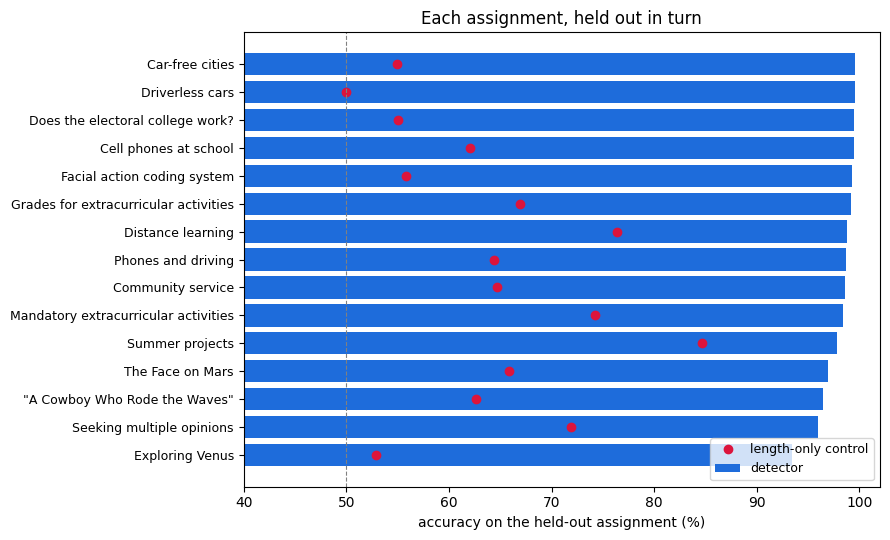

In [11]:
if not runs.empty:
    d = summ.sort_values('accuracy')
    fig, ax = plt.subplots(figsize=(9,5.5))
    y = np.arange(len(d))
    ax.barh(y, 100*d['accuracy'], color='#1E6CDB', label='detector')
    ax.plot(100*d['length_only'], y, 'o', color='crimson', ms=6, label='length-only control')
    ax.axvline(50, color='grey', ls='--', lw=0.8)
    ax.set_yticks(y); ax.set_yticklabels(d['topic'], fontsize=9)
    ax.set_xlabel('accuracy on the held-out assignment (%)'); ax.set_xlim(40,102)
    ax.legend(fontsize=9, loc='lower right')
    ax.set_title('Each assignment, held out in turn')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS,'fig_loto.pdf'), bbox_inches='tight')
    plt.savefig(os.path.join(FIGS,'fig_loto.png'), dpi=200, bbox_inches='tight')
    plt.show()

## 6. RQ2 --- who absorbs the false accusations

Only authentic essays enter this, because only authentic work can be falsely
accused. Each is joined to what PERSUADE records about its writer, on the essay
identifier rather than row position.

In [12]:
MIN_N = 30
GROUPS = [('holistic_essay_score','holistic grade'),
          ('ell_status','English an additional language'),
          ('grade_level','school year'),
          ('economically_disadvantaged','economic disadvantage'),
          ('student_disability_status','disability status')]

pers = pd.read_csv(PERSUADE, low_memory=False)
pers['uid'] = pers['full_text'].map(h)
pmeta = pers.drop_duplicates('uid').set_index('uid')

if runs.empty:
    print('no runs yet')
else:
    frames = []
    for r in runs[runs.seed==42].itertuples():
        f = os.path.join(PREDS,'preds_f%02d_%s_seed%d.csv'%(r.fold,r.model,r.seed))
        if not os.path.exists(f): continue
        pr = pd.read_csv(f); pr['fold'] = r.fold; frames.append(pr)
    allp = pd.concat(frames, ignore_index=True)
    auth = allp[allp.label==0].join(pmeta[[g for g,_ in GROUPS]], on='uid', how='inner')
    print('authentic essays with writer information: %d of %d (%.0f%%)'
          % (len(auth), (allp.label==0).sum(), 100*len(auth)/max((allp.label==0).sum(),1)))
    rows = []
    for col, lab in GROUPS:
        sub = auth.dropna(subset=[col])
        for val, grp in sub.groupby(col):
            if len(grp) < MIN_N: continue
            rows.append({'group':lab,'value':str(val),'n':len(grp),
                         'false_positive_rate':grp['pred'].mean()})
    fair = pd.DataFrame(rows)
    fair.to_csv(os.path.join(RESULTS,'loto_fairness.csv'), index=False)
    for lab in fair['group'].unique():
        s = fair[fair['group']==lab]
        print('\n--- by %s ---' % lab)
        print(s.assign(FPR_pct=(100*s.false_positive_rate).round(2))
              [['value','n','FPR_pct']].to_string(index=False))

authentic essays with writer information: 13202 of 14183 (93%)

--- by holistic grade ---
value    n  FPR_pct
    1  434     0.92
    2 2314     1.30
    3 3805     1.47
    4 3846     3.35
    5 2166     4.29
    6  637     5.18

--- by English an additional language ---
value     n  FPR_pct
   No 11483     2.87
  Yes  1271     0.63

--- by school year ---
value    n  FPR_pct
  6.0  523     6.88
  8.0 4771     3.69
  9.0 1309     0.92
 10.0 3396     1.71
 11.0 2387     2.35
 12.0  401     0.00

--- by economic disadvantage ---
                         value    n  FPR_pct
    Economically disadvantaged 4223     1.52
Not economically disadvantaged 5756     4.41

--- by disability status ---
                              value    n  FPR_pct
    Identified as having disability 1330     1.58
Not identified as having disability 8667     3.43


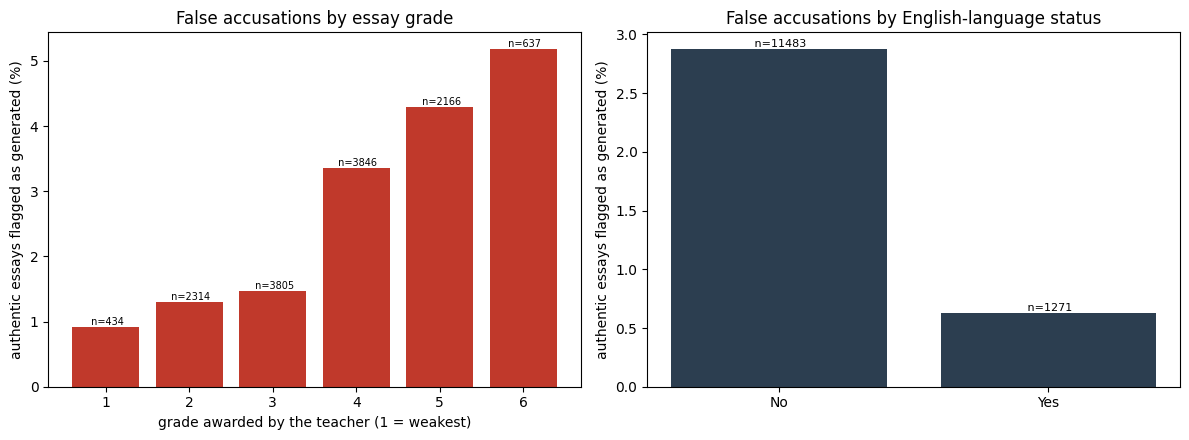

In [13]:
if not runs.empty and not fair.empty:
    g = fair[fair['group']=='holistic grade'].copy()
    g['value'] = g['value'].astype(float); g = g.sort_values('value')
    e = fair[fair['group']=='English an additional language']
    fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
    axes[0].bar(g['value'], 100*g['false_positive_rate'], color='#C0392B')
    axes[0].set_xlabel('grade awarded by the teacher (1 = weakest)')
    axes[0].set_ylabel('authentic essays flagged as generated (%)')
    axes[0].set_title('False accusations by essay grade')
    for x, v, n in zip(g['value'], 100*g['false_positive_rate'], g['n']):
        axes[0].text(x, v, ' n=%d'%n, ha='center', va='bottom', fontsize=7)
    if not e.empty:
        axes[1].bar(e['value'], 100*e['false_positive_rate'], color='#2C3E50')
        axes[1].set_ylabel('authentic essays flagged as generated (%)')
        axes[1].set_title('False accusations by English-language status')
        for x, v, n in zip(range(len(e)), 100*e['false_positive_rate'], e['n']):
            axes[1].text(x, v, ' n=%d'%n, ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS,'fig_fairness.pdf'), bbox_inches='tight')
    plt.savefig(os.path.join(FIGS,'fig_fairness.png'), dpi=200, bbox_inches='tight')
    plt.show()

## 7. Why? The mechanism behind RQ2

Run this only if section 6 showed an uneven distribution. A correlation is not
an explanation, so one mechanism is tested: that the detector learned formal
polish as evidence of generation.

The marker list below is fixed from the discourse literature, **before** any
attribution is computed, so the two parts cannot be tuned to agree.

In [14]:
MARKERS = ['however','furthermore','moreover','additionally','consequently',
           'therefore','nevertheless','nonetheless','in conclusion','in addition',
           'for instance','as a result','on the other hand','in contrast',
           'ultimately','notably','significantly','essentially','overall','thus']

def marker_rate(text):
    t = ' ' + str(text).lower() + ' '
    words = max(len(t.split()), 1)
    hits = sum(len(re.findall(r'\b%s\b' % re.escape(mk), t)) for mk in MARKERS)
    return 1000.0 * hits / words

# the premise: is the signal even there to be learned?
k = labelled.copy(); k['markers_per_1k'] = k['text'].map(marker_rate)
print('formal markers per 1000 words')
print(k.groupby('label')['markers_per_1k'].agg(['mean','median','count'])
      .rename(index={0:'student',1:'generated'}).round(2).to_string())

formal markers per 1000 words
           mean  median  count
label                         
student    1.92    0.00  27367
generated  7.78    6.96  17494


### 7a. Part A --- every authentic essay, no sampling

In [15]:
if runs.empty:
    print('no runs yet')
else:
    te_all = pd.concat([pd.read_csv(os.path.join(LOTO,'fold_%02d_test.csv'%r.fold))
                        .assign(fold=r.fold) for r in folds.itertuples()],
                       ignore_index=True)
    a = auth.merge(te_all[['uid','text']], on='uid', how='left').dropna(subset=['text'])
    a['markers'] = a['text'].map(marker_rate)
    a['grade'] = a['holistic_essay_score'].astype(int)
    a['words'] = a['text'].str.split().str.len()
    print('authentic essays analysed: %d (no sampling)' % len(a))
    print()
    print('correlation with being flagged as generated')
    for c, lab in [('grade','essay grade'),('markers','marker density'),('words','word count')]:
        print('   %-16s %+.3f' % (lab, a[c].corr(a['pred'])))
    print('   grade vs markers %+.3f' % a['grade'].corr(a['markers']))
    print()
    print(a.groupby('grade').agg(n=('pred','size'),
          flagged_pct=('pred', lambda s: round(100*s.mean(),2)),
          markers_per_1k=('markers','mean'), median_words=('words','median')
          ).round(2).to_string())
    print()
    print('within each grade: marker density of flagged vs passed essays')
    rows = []
    for grade, grp in a.groupby('grade'):
        f_, u_ = grp[grp.pred==1]['markers'], grp[grp.pred==0]['markers']
        if len(f_) < 15 or len(u_) < 15: continue
        rows.append({'grade':grade,'n_flagged':len(f_),'n_passed':len(u_),
                     'markers_flagged':f_.mean(),'markers_passed':u_.mean(),
                     'difference':f_.mean()-u_.mean()})
    if rows:
        w = pd.DataFrame(rows); print(w.round(2).to_string(index=False))
        w.to_csv(os.path.join(RESULTS,'rq2_markers_within_grade.csv'), index=False)
        pos = (w['difference']>0).sum()
        print('\ngrades where flagged essays are more marker-dense: %d of %d' % (pos, len(w)))
        if pos == len(w) and len(w) >= 3:
            print('-> consistent: polish predicts a flag beyond what grade explains')
        elif pos <= len(w)/2:
            print('-> NOT supported. Do not claim polish as the mechanism;')
            print('   report the grade effect as unexplained.')
        else:
            print('-> mixed; suggestive only')
    else:
        print('too few flagged essays per grade to test')
    a[['uid','fold','grade','markers','words','pred']].to_csv(
        os.path.join(RESULTS,'rq2_marker_density.csv'), index=False)

authentic essays analysed: 13202 (no sampling)

correlation with being flagged as generated
   essay grade      +0.078
   marker density   +0.090
   word count       +0.034
   grade vs markers +0.260

          n  flagged_pct  markers_per_1k  median_words
grade                                                 
1       434         0.92            0.78         254.0
2      2314         1.30            1.24         237.0
3      3805         1.47            1.68         340.0
4      3846         3.35            2.40         468.0
5      2166         4.29            3.14         643.0
6       637         5.18            3.97         840.0

within each grade: marker density of flagged vs passed essays
 grade  n_flagged  n_passed  markers_flagged  markers_passed  difference
     2         30      2284             2.52            1.22        1.30
     3         56      3749             3.07            1.66        1.41
     4        129      3717             3.45            2.37        1.08
    

### 7b. Part B --- LIME on real false accusations

In [16]:
LIME_FOLD, N_EXPLAIN, NUM_SAMPLES = 0, 60, 500
cd = os.path.join(CKPT, 'f%02d_%s_seed42' % (LIME_FOLD, MODEL))
STOP = set(("a an the and or but if while of to in on at by for with from as is are "
            "was were be been being it its this that these those there here we our "
            "you your they their he she his her not no than then so such can could "
            "would should may might will just also very more most other some any "
            "each which who whom what when where how why do does did done have has "
            "had i me my").split())
try:
    from lime.lime_text import LimeTextExplainer
    HAVE = os.path.isdir(cd)
except ImportError:
    HAVE = False; print('lime not installed')

if runs.empty or not HAVE:
    print('needs a completed fold %d and a kept checkpoint at %s' % (LIME_FOLD, cd))
else:
    tok = AutoTokenizer.from_pretrained(cd)
    model = AutoModelForSequenceClassification.from_pretrained(cd).to(DEVICE).eval()
    def proba(texts):
        out = []
        for i in range(0, len(texts), 16):
            enc = tok(list(texts[i:i+16]), max_length=256, truncation=True,
                      padding='max_length', return_tensors='pt').to(DEVICE)
            with torch.no_grad(): out.append(torch.softmax(model(**enc).logits,1).cpu().numpy())
        return np.vstack(out)

    sub = a[a.fold==LIME_FOLD]
    flagged = sub[(sub.pred==1) & (sub.grade>=5)]
    passed  = sub[(sub.pred==0) & (sub.grade<=2)]
    print('fold %d: %d flagged high-grade, %d passed low-grade'
          % (LIME_FOLD, len(flagged), len(passed)))
    if len(flagged) < 10:
        print('too few high-grade false positives here; report Part A only')
    else:
        expl = LimeTextExplainer(class_names=['authentic','generated'])
        rows = []
        for nm, grp in [('flagged_high_grade',flagged), ('passed_low_grade',passed)]:
            take = grp.sample(min(N_EXPLAIN,len(grp)), random_state=SEED)
            for i, r in enumerate(take.itertuples(), 1):
                ex = expl.explain_instance(str(r.text)[:2000], proba, num_features=12,
                                           num_samples=NUM_SAMPLES, labels=(1,))
                for tk, wt in ex.as_list(label=1):
                    t = tk.lower().strip()
                    if t and t not in STOP and t.isalpha() and len(t) > 2:
                        rows.append({'group':nm,'token':t,'weight':wt,'grade':r.grade})
                if i % 10 == 0: print('   %s %d/%d' % (nm, i, len(take)), flush=True)
        lime_df = pd.DataFrame(rows)
        lime_df.to_csv(os.path.join(RESULTS,'rq2_lime_tokens.csv'), index=False)
        top = (lime_df[lime_df.group=='flagged_high_grade']
               .groupby('token')['weight'].agg(['mean','count']).reset_index())
        top = top[top['count']>=3].sort_values('mean', ascending=False)
        print('\nstrongest tokens pushing a high-grade authentic essay toward "generated"')
        print(top.head(20).round(4).to_string(index=False))
        mk = set(m for m in MARKERS if ' ' not in m)
        share = top.head(30)['token'].isin(mk).mean()
        print('\nshare of the top 30 that are pre-registered markers: %.0f%%' % (100*share))
        print('-> consistent with Part A' if share >= 0.20 else
              '-> NOT mainly markers; do not claim LIME corroborates Part A')
        del model, tok; gc.collect(); torch.cuda.empty_cache()

fold 0: 21 flagged high-grade, 100 passed low-grade
   flagged_high_grade 10/21
   flagged_high_grade 20/21
   passed_low_grade 10/60
   passed_low_grade 20/60
   passed_low_grade 30/60
   passed_low_grade 40/60
   passed_low_grade 50/60
   passed_low_grade 60/60

strongest tokens pushing a high-grade authentic essay toward "generated"
   token   mean  count
distance 0.0215      3
    many 0.0081      3
 classes 0.0074      3

share of the top 30 that are pre-registered markers: 0%
-> NOT mainly markers; do not claim LIME corroborates Part A


## 8. The abstract side probe --- check the rule before using it

In [17]:
if os.path.exists(ABS_RUNS):
    ab = pd.read_csv(ABS_RUNS)
    s = ab[ab.seed==42]
    print('folds scored: %d' % len(s))
    print(s[['fold','accuracy','recall','roc_auc','fpr']].round(4).to_string(index=False))
    spread = 100*(s.accuracy.max()-s.accuracy.min()); mean = 100*s.accuracy.mean()
    collapse = ((s.recall > 0.98) & (s.fpr > 0.9)).mean()
    print()
    print('spread across folds : %.1f points   (rule: <= 15)' % spread)
    print('mean accuracy       : %.2f%%        (rule: < 90)' % mean)
    print('single-class collapse in %.0f%% of folds' % (100*collapse))
    print()
    ok = spread <= 15 and mean < 90
    if collapse > 0.5:
        print('COLLAPSE: describe as a collapse with both rates, never as an accuracy.')
    print('INCLUDE as one sentence in related work' if ok else
          'EXCLUDE from the paper - see results/DECISIONS.md')
else:
    print('no abstract probe results yet')

folds scored: 15
 fold  accuracy  recall  roc_auc    fpr
    0    0.5987     1.0   0.9450 0.8026
    1    0.5132     1.0   0.6289 0.9737
    2    0.5000     1.0   0.8138 1.0000
    3    0.5395     1.0   0.9374 0.9211
    4    0.5296     1.0   0.9432 0.9408
    5    0.5428     1.0   0.5515 0.9145
    6    0.5033     1.0   0.9192 0.9934
    7    0.5132     1.0   0.9530 0.9737
    8    0.5132     1.0   0.5430 0.9737
    9    0.5066     1.0   0.6665 0.9868
   10    0.5099     1.0   0.7464 0.9803
   11    0.5033     1.0   0.8215 0.9934
   12    0.5296     1.0   0.8463 0.9408
   13    0.5000     1.0   0.8598 1.0000
   14    0.5855     1.0   0.9246 0.8289

spread across folds : 9.9 points   (rule: <= 15)
mean accuracy       : 52.59%        (rule: < 90)
single-class collapse in 87% of folds

COLLAPSE: describe as a collapse with both rates, never as an accuracy.
INCLUDE as one sentence in related work


## 9. LaTeX for the paper

In [18]:
def fmt(x, nd=2): return '--' if (x is None or x != x) else '%.*f' % (nd, 100*x)

if not runs.empty:
    L = [r'\begin{table}[t]', r'\centering', r'\small',
         r'\caption{Leave-one-assignment-out. Each row trains on the other 14',
         r'assignments and marks only the one named. Generated text is the positive',
         r'class; all figures are percentages. Controls are fitted separately on',
         r'each fold and cannot recognise authorship.}', r'\label{tab:loto}',
         r'\begin{tabular}{@{}lrrrrr@{}}', r'\toprule',
         (r'\textbf{Held-out assignment} & \textbf{Test $n$} & \textbf{Acc.} & '
          r'\textbf{Recall} & \textbf{ROC} & \textbf{vs.\ length} \\'), r'\midrule']
    for r in summ.itertuples():
        L.append('%s & %s & %s & %s & %s & %+.1f \\\\'
                 % (str(r.topic).replace('"','``',1),
                    '{:,}'.format(int(r.n_test)).replace(',','{,}'),
                    fmt(r.accuracy), fmt(r.recall), fmt(r.roc_auc), r.margin_pts))
    L += [r'\midrule',
          r'\textbf{Mean over folds} & & %s & %s & %s & %+.1f \\'
          % (fmt(summ.accuracy.mean()), fmt(summ.recall.mean()),
             fmt(summ.roc_auc.mean()), summ.margin_pts.mean()),
          r'\textbf{Worst fold} & & %s & %s & %s & %+.1f \\'
          % (fmt(summ.accuracy.min()), fmt(summ.recall.min()),
             fmt(summ.roc_auc.min()), summ.margin_pts.min()), r'\midrule',
          r'\emph{word-frequency control, mean} & & %s & & & \\' % fmt(summ.tfidf.mean()),
          r'\emph{length-only control, mean} & & %s & & & \\' % fmt(summ.length_only.mean()),
          r'\bottomrule', r'\end{tabular}', r'\end{table}']
    open(os.path.join(RESULTS,'table_loto.tex'),'w',encoding='utf-8').write('\n'.join(L)+'\n')

    F = [r'\begin{table}[t]', r'\centering', r'\small',
         r'\caption{The false-positive rate on authentic student work, pooled over',
         r'the 15 held-out assignments. Every figure is an accusation against a',
         r'student who did their own work.}', r'\label{tab:fairness}',
         r'\begin{tabular}{@{}lrr@{}}', r'\toprule',
         r'\textbf{Writer group} & \textbf{Essays} & \textbf{False-positive rate} \\',
         r'\midrule']
    for lab in ['holistic grade','English an additional language']:
        s = fair[fair['group']==lab]
        if s.empty: continue
        F.append(r'\multicolumn{3}{@{}l}{\emph{by %s}} \\' % lab)
        for r in s.itertuples():
            F.append(r'\quad %s & %s & %.2f \\'
                     % (r.value, '{:,}'.format(int(r.n)).replace(',','{,}'),
                        100*r.false_positive_rate))
        F.append(r'\midrule')
    F[-1] = r'\bottomrule'; F += [r'\end{tabular}', r'\end{table}']
    open(os.path.join(RESULTS,'table_fairness.tex'),'w',encoding='utf-8').write('\n'.join(F)+'\n')
    print('wrote results/table_loto.tex and results/table_fairness.tex')
    print(open(os.path.join(RESULTS,'table_loto.tex'),encoding='utf-8').read())

wrote results/table_loto.tex and results/table_fairness.tex
\begin{table}[t]
\centering
\small
\caption{Leave-one-assignment-out. Each row trains on the other 14
assignments and marks only the one named. Generated text is the positive
class; all figures are percentages. Controls are fitted separately on
each fold and cannot recognise authorship.}
\label{tab:loto}
\begin{tabular}{@{}lrrrrr@{}}
\toprule
\textbf{Held-out assignment} & \textbf{Test $n$} & \textbf{Acc.} & \textbf{Recall} & \textbf{ROC} & \textbf{vs.\ length} \\
\midrule
Distance learning & 4{,}314 & 98.79 & 98.70 & 99.85 & +22.4 \\
Car-free cities & 4{,}102 & 99.61 & 99.85 & 99.99 & +44.6 \\
Does the electoral college work? & 3{,}440 & 99.48 & 99.94 & 100.00 & +44.5 \\
Seeking multiple opinions & 3{,}104 & 96.01 & 99.16 & 99.68 & +24.1 \\
Mandatory extracurricular activities & 2{,}812 & 98.36 & 99.43 & 99.82 & +24.1 \\
Summer projects & 1{,}902 & 97.79 & 99.26 & 99.81 & +13.1 \\
Facial action coding system & 1{,}834 & 99.24

## 10. Outputs

| File | Contents |
|---|---|
| `results/loto_runs.csv` | one row per fold and seed |
| `results/loto_baselines.csv` | both controls, per fold |
| `results/loto_summary.csv` | per-fold results with the control margin |
| `results/loto_fairness.csv` | false-positive rate by writer group |
| `results/loto_abstract_probe.csv` | the side probe, governed by DECISIONS.md |
| `results/rq2_marker_density.csv` | marker density and verdict per essay |
| `results/rq2_markers_within_grade.csv` | flagged vs passed, within grade |
| `results/rq2_lime_tokens.csv` | LIME tokens on real false accusations |
| `results/table_loto.tex` | RQ1 table, paste into the paper |
| `results/table_fairness.tex` | RQ2 table, paste into the paper |
| `results/figures/fig_loto.*` | per-assignment accuracy against the control |
| `results/figures/fig_fairness.*` | false accusations by grade and language |

Then replace the pending cells in `paper/iciser2026_short.tex` and re-check the
length with `python scripts/audit/wc.py`.